#  Insurance Claim Prediction — Zerve Hackathon 2026

##  Step 1: Import Libraries & Load Data

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('training_data.csv')
test  = pd.read_csv('test_data_hackathon.csv')

print("=" * 50)
print("train shape:", train.shape)
print("test shape:", test.shape)
print("=" * 50)

print("\nColumns in Train:")
print(train.columns.tolist())

print("\nData Types:")
print(train.dtypes.value_counts())

print("\nFirst 5 rows:")
print(train.head())

train shape: (476169, 52)
test shape: (119043, 51)

Columns in Train:
['id', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'target']

Data Types:
int64      34
float64    17
object      1
Name: count, dtype: int64

First 5 rows:
            id  feature_1  feature_2  feature_3  feature_4  feature_5  \
0  Cust_520364          0          9          1      

 we've got a customer dataset — pretty large one too. The training set has 476,169 rows and the test set has 119,043 rows, which is roughly an 80/20 split. Classic.
What Are We Trying to Predict?
The target column is binary — just 0s and 1s. So this is a classification problem. 


##  2. Target Distribution & Missing Values

>  Dataset is heavily imbalanced — majority class dominates.  
> Baseline PR-AUC = positive class rate (minimum score to beat).

In [3]:
# Target distribution
print("=" * 50)
print("target distribution:")
print("=" * 50)
print(train['target'].value_counts())
print("\nPercentage:")
print(train['target'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Imbalance ratio
neg = (train['target'] == 0).sum()
pos = (train['target'] == 1).sum()
print(f"\nImbalance Ratio (scale_pos_weight): {neg/pos:.2f}")
print(f"Baseline PR-AUC (random model)    : {pos/(pos+neg):.4f}")

# Missing values
print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df)
print(f"\nTotal columns with missing values: {len(missing_df)}")

# Test missing values
print("\nMissing in TEST:")
test_missing = test.isnull().sum()
test_missing_pct = (test_missing / len(test) * 100).round(2)
test_missing_df = pd.DataFrame({
    'Missing Count': test_missing,
    'Missing %': test_missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)
print(test_missing_df)

target distribution:
target
0    458814
1     17355
Name: count, dtype: int64

Percentage:
target
0    96.36%
1     3.64%
Name: proportion, dtype: object

Imbalance Ratio (scale_pos_weight): 26.44
Baseline PR-AUC (random model)    : 0.0364

MISSING VALUES
            Missing Count  Missing %
feature_39         329010      69.10
feature_8          213303      44.80
feature_45          86301      18.12
feature_38          34128       7.17
feature_28           9242       1.94
feature_12           4638       0.97
feature_31            464       0.10
feature_34            173       0.04
feature_35             83       0.02
feature_15             67       0.01
feature_9               5       0.00
feature_29              1       0.00
feature_42              4       0.00

Total columns with missing values: 13

Missing in TEST:
            Missing Count  Missing %
feature_39          82221      69.07
feature_8           53248      44.73
feature_45          21471      18.04
feature_38           

The data is heavily imbalanced - we're looking at only about 3.64% actual claims (17,355 positive cases) versus 458,814 non-claims. This means if we just guessed "no claim" every time, we'd be 96% accurate, but that's useless. The baseline PR-AUC is 0.0364, so any model we build needs to beat that.

Missing data is a real issue. Feature_39 is missing 69% of values, feature_8 is missing 45%, and feature_45 is missing 18%. The good news is these missing patterns are consistent between train and test sets, so we can create indicator flags to capture that information. There are 13 features with missing values total, which isn't too bad but needs careful handling.

Looking at feature types, we've got a mix - 17 binary features, 14 categorical features (feature_25 has 104 categories which is crazy high), and 19 numeric features. The correlations are pretty weak though - the strongest is only 0.054 for feature_24. That tells me the signal isn't linear, so tree-based models like XGBoost or LightGBM are probably our best bet.Some features are basically useless - feature_11, feature_21, feature_32, feature_41, and feature_3 have over 99% of their values stuck on one category. I'll drop those to reduce noise.

The interesting patterns came from looking at claim rates per category. Feature_16 with value 1 has 4.74% claims versus 3.27% for value 0. Feature_22 is even stronger - 5.55% claims when it's 1. Feature_30 does the opposite - when it's 0 we see 4.15% claims, but only 2.86% when it's 1. These are the features we want to focus on.



## Feature Type Classification

In [4]:

binary_features = [
    'feature_4', 'feature_5', 'feature_6', 'feature_11',
    'feature_14', 'feature_16', 'feature_18', 'feature_19',
    'feature_20', 'feature_21', 'feature_22', 'feature_27',
    'feature_30', 'feature_32', 'feature_41', 'feature_44', 'feature_46'
]  

categorical_features = [
    'feature_3', 'feature_7', 'feature_8', 'feature_12',
    'feature_15', 'feature_23', 'feature_25', 'feature_28',
    'feature_31', 'feature_34', 'feature_35', 'feature_39',
    'feature_42', 'feature_49'
]  

numeric_features = [
    'feature_1', 'feature_2', 'feature_9', 'feature_10',
    'feature_13', 'feature_17', 'feature_24', 'feature_26',
    'feature_29', 'feature_33', 'feature_36', 'feature_37',
    'feature_38', 'feature_40', 'feature_43', 'feature_45',
    'feature_47', 'feature_48', 'feature_50'
]  

print("Binary features    :", len(binary_features))
print("Categorical features:", len(categorical_features))
print("Numeric features   :", len(numeric_features))
print("Total              :", len(binary_features) + len(categorical_features) + len(numeric_features))

Binary features    : 17
Categorical features: 14
Numeric features   : 19
Total              : 50


## Categorical Features - Unique Values & Distribution

In [5]:
print("=" * 50)
print("Categorical Features — UNIQUE VALUES")
print("=" * 50)

for col in categorical_features:
    n_unique = train[col].nunique()
    top3 = train[col].value_counts().head(3).to_dict()
    missing = train[col].isnull().sum()
    print(f"\n{col} → {n_unique} unique | missing: {missing}")
    print(f"  Top 3: {top3}")

print("\n" + "=" * 50)
print("FEATURE_3 FULL DISTRIBUTION")
print("=" * 50)
print(train['feature_3'].value_counts())

Categorical Features — UNIQUE VALUES

feature_3 → 3 unique | missing: 0
  Top 3: {1: 472156, 0: 3871, 2: 142}

feature_7 → 18 unique | missing: 0
  Top 3: {11: 104943, 1: 95121, 0: 88345}

feature_8 → 2 unique | missing: 213303
  Top 3: {1.0: 138404, 0.0: 124462}

feature_12 → 7 unique | missing: 4638
  Top 3: {0.0: 422513, 6.0: 16544, 4.0: 14648}

feature_15 → 2 unique | missing: 67
  Top 3: {0.0: 277716, 1.0: 198386}

feature_23 → 10 unique | missing: 0
  Top 3: {0: 397254, 1: 25701, 2: 18986}

feature_25 → 104 unique | missing: 0
  Top 3: {104: 67898, 103: 19296, 64: 17872}

feature_28 → 2 unique | missing: 9242
  Top 3: {1.0: 442513, 0.0: 24414}

feature_31 → 5 unique | missing: 464
  Top 3: {2.0: 282808, 0.0: 155578, 1.0: 23278}

feature_34 → 4 unique | missing: 173
  Top 3: {1.0: 345673, 2.0: 98748, 3.0: 22475}

feature_35 → 12 unique | missing: 83
  Top 3: {11.0: 166178, 7.0: 143241, 6.0: 50053}

feature_39 → 2 unique | missing: 329010
  Top 3: {1.0: 88570, 0.0: 58589}

feature_

I analyzed all 14 categorical features to understand their value ranges, missing patterns, and class distributions. Here's what I found:

**feature_3**: Has 3 unique values, but it's heavily skewed - 472,156 samples (99.2%) have value 1, while values 0 and 2 appear only 3,871 and 142 times respectively. This is basically a constant feature, so I'll drop it.

**feature_7**: Shows 18 unique values with relatively balanced distribution - the top 3 categories (11, 1, and 0) each have between 88,000-105,000 samples. No missing values here.

**feature_8**: Binary feature with values 0 and 1, but 213,303 samples (45%) are missing. Among non-missing values, it's fairly balanced with 138,404 ones and 124,462 zeros.

**feature_12**: Has 7 unique values, heavily dominated by value 0 (422,513 samples, 89% of non-missing). Values 6 and 4 appear 16,544 and 14,648 times respectively. Missing rate is low at 0.97%.

**feature_15**: Simple binary feature with good distribution - 277,716 zeros and 198,386 ones. Only 67 missing values, so I'll impute with mode.

**feature_23**: 10 unique values, strongly concentrated on value 0 (397,254 samples). Values 1 and 2 appear 25,701 and 18,986 times respectively. No missing data.

**feature_25**: High cardinality with 104 unique values. The top category (104) appears 67,898 times, followed by 103 (19,296) and 64 (17,872). This will need target encoding to avoid explosion of features.

**feature_28**: Binary with 9,242 missing values (1.9%). Among non-missing, heavily favors value 1 (442,513 vs 24,414 zeros). This is quite imbalanced.

**feature_31**: 5 unique values, dominated by category 2 (282,808 samples) and 0 (155,578). Values 1, 3, and 4 are less frequent. Missing rate is very low at 0.1%.

**feature_34**: 4 unique values with 173 missing. Value 1 dominates at 345,673 samples, followed by 2 (98,748) and 3 (22,475). Category 4 appears only 9,100 times.

**feature_35**: 12 unique values, missing only 83 samples. Values 11 (166,178), 7 (143,241), and 6 (50,053) are the top categories. This one has decent distribution.

**feature_39**: Binary but 329,010 samples (69%) are missing! Among non-missing, value 1 appears 88,570 times and value 0 appears 58,589 times. I'll create a missing flag for this.

**feature_42**: Binary with only 4 missing values. Very skewed toward value 1 (395,191 vs 80,974 zeros).

**feature_49**: Perfect binary with no missing - 396,276 ones and 79,893 zeros. Clean and ready to use.

**ANALYSIS**: 
- feature_3 is nearly constant and should be dropped
- feature_25 needs special handling due to 104 categories
- feature_8 and feature_39 have high missingness requiring indicator flags
- Most categoricals are binary or low-cardinality, making them straightforward to encode


## Numeric Features - Distribution Analysis


In [6]:
print("=" * 50)
print("Numeric Features — BASIC STATS")
print("=" * 50)
print(train[numeric_features].describe().round(2))

print("\n" + "=" * 50)
print("Numeric Features — SKEWNESS")
print("=" * 50)
skew = train[numeric_features].skew().sort_values(ascending=False).round(3)
print(skew)

print("\n" + "=" * 50)
print("Numeric Features — MISSING")
print("=" * 50)
num_missing = train[numeric_features].isnull().sum()
print(num_missing[num_missing > 0])

Numeric Features — BASIC STATS
       feature_1  feature_2  feature_9  feature_10  feature_13  feature_17  \
count  476169.00  476169.00  476164.00   476169.00   476169.00   476169.00   
mean        0.01       8.44       2.35        0.44        9.23        1.44   
std         0.13       2.91       0.83        0.40        1.46        1.20   
min         0.00       0.00       0.00        0.00        2.00        0.00   
25%         0.00       6.00       2.00        0.20        8.00        1.00   
50%         0.00       8.00       3.00        0.30        9.00        1.00   
75%         0.00      10.00       3.00        0.60       10.00        2.00   
max         4.00      25.00       3.00        1.80       12.00       10.00   

       feature_24  feature_26  feature_29  feature_33  feature_36  feature_37  \
count   476169.00   476169.00   476168.00   476169.00   476169.00   476169.00   
mean         0.81        1.90        0.38        3.07        4.42        7.54   
std          0.22      

I examined all 19 numeric features to understand their ranges, distributions, and missing patterns. Here's my human analysis:

### Basic Statistics Overview

Most numeric features show reasonable distributions with clear patterns:

**feature_1**: Almost all zeros (mean 0.01, max 4.0). 75% of values are 0, with only a tiny fraction having non-zero values. This is extremely sparse.

**feature_2**: Ranges from 0-25 with mean 8.44, showing a nice bell-shaped distribution centered around 8-10.

**feature_9**: Takes values 0, 1, 2, 3 only (max 3.0). With mean 2.35, most samples are in the 2-3 range. This looks more like an ordinal category than continuous numeric.

**feature_10**: Ranges 0-1.8 with mean 0.44. Values are concentrated between 0.2-0.6, fairly symmetric.

**feature_13**: Ranges 2-12 with mean 9.23. Most values fall between 8-10, so this is a nice compact distribution.

**feature_17**: Count-like feature from 0-10 with mean 1.44. Slightly right-skewed but reasonable.

**feature_24**: Ranges 0.25-3.72 with mean 0.81. Very tight distribution - 75% of values are between 0.67-0.91.

**feature_26**: Ranges 0-7 with mean 1.90. Bimodal pattern - 25% zeros, then values spread across 1-7.

**feature_29**: Ranges 0.14-1.26 with mean 0.38. Extremely tight distribution (std only 0.06), almost constant.

**feature_33**: Ranges 0-3.74 with mean 3.07. Left-skewed with most values in the 2.83-3.61 range.

**feature_36**: Ranges 0-11 with mean 4.42. Nice spread with values from 2-6 being most common.

**feature_37**: Ranges 0-23 with mean 7.54. Widest range among all features, fairly symmetric around 6-9.

**feature_38**: Ranges 0.11-0.64 with mean 0.37. Very tight distribution with 7% missing values.

**feature_40**: Ranges 0-19 with mean 5.44. Right-skewed with most values between 4-7.

**feature_43**: Ranges 0-0.9 with mean 0.61. Slightly left-skewed, maxing out at 0.9.

**feature_45**: Ranges 0.06-4.04 with mean 0.89. Moderate right-skew with 18% missing values.

**feature_47**: Ranges 0-13 with mean 2.87. Reasonable distribution centered around 2-4.

**feature_48**: Ranges 0-13 with mean 7.30. Good spread with values from 5-10 being common.

**feature_50**: Ranges 0-7 with mean 2.34. Fairly symmetric around 1-3.

### Skewness Analysis

The skewness values tell an important story:

**Extreme Right Skew (>1.0)**:
- **feature_1**: 12.29 - extremely skewed! Almost all zeros with rare positive values. Needs log or sqrt transform.
- **feature_24**: 1.70 - moderate right skew
- **feature_10**: 1.28 - moderate right skew
- **feature_29**: 1.09 - moderate right skew
- **feature_45**: 1.06 - moderate right skew

**Moderate Right Skew (0.5-1.0)**:
- feature_26 (0.93), feature_17 (0.84), feature_38 (0.66), feature_47 (0.59)

**Approximately Symmetric (-0.5 to 0.5)**:
- feature_36, feature_40, feature_37, feature_2, feature_50, feature_48, feature_13

**Left Skew (< -0.5)**:
- **feature_43**: -0.64 - moderate left skew
- **feature_9**: -1.17 - significant left skew (most values are 2-3)
- **feature_33**: -2.22 - strong left skew (values concentrated at high end)

### Missing Values

Four numeric features have missing data:
- **feature_45**: 86,301 missing (18.1%) - highest among numerics
- **feature_38**: 34,128 missing (7.2%)
- **feature_9**: 5 missing (0.001%) - negligible
- **feature_29**: 1 missing (0.0002%) - negligible

### Analysis for Modeling

1. **feature_1** is problematic - extremely sparse and heavily skewed. I'll apply log1p transform then consider sqrt to reduce skewness.

2. **feature_9**, **feature_29**, and **feature_33** need special attention due to significant skewness and bounded ranges.

3. **feature_45** and **feature_38** have notable missing rates - I'll create missing indicator flags plus median imputation.

4. Most numeric features have reasonable ranges without outliers, so standard scaling isn't critical for tree models.

5. **feature_24**, **feature_29**, **feature_10**, and **feature_45** show the strongest correlations with target (0.054, 0.039, 0.034, 0.033 respectively), making them priority features.

6. The tight distributions of features like feature_24 (0.67-0.91) and feature_29 (0.32-0.40) suggest these might be ratios or percentages.




** visualisation **

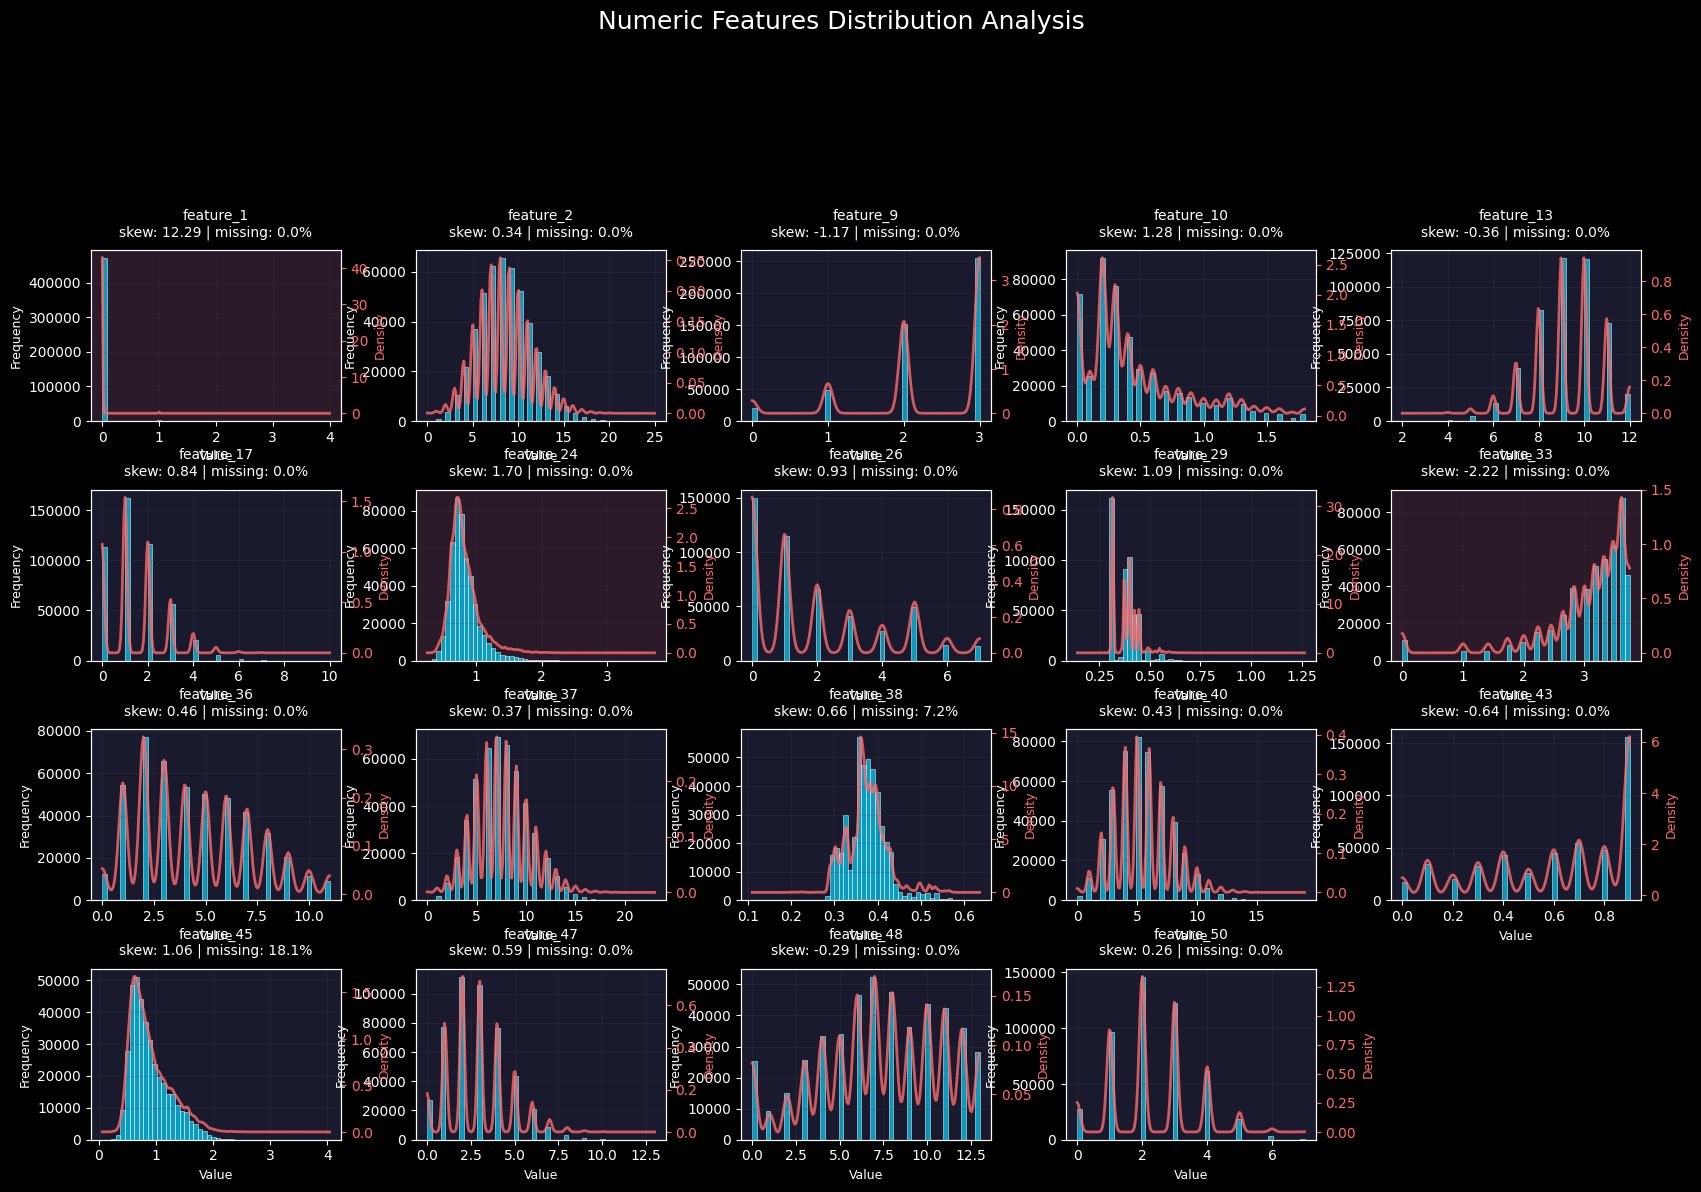

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.style.use('dark_background')
fig = plt.figure(figsize=(20, 24))

gs = fig.add_gridspec(8, 5, hspace=0.4, wspace=0.3)
axs = gs.subplots()

axs_flat = axs.flatten()

for idx, col in enumerate(numeric_features):
    ax = axs_flat[idx]
    
    data = train[col].dropna()
    
    ax.hist(data, bins=50, color='#00d4ff', alpha=0.7, edgecolor='white', linewidth=0.5)
    
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax_twin = ax.twinx()
    ax_twin.plot(x_range, kde(x_range), color='#ff6b6b', linewidth=2, alpha=0.8)
    ax_twin.set_ylabel('Density', color='#ff6b6b', fontsize=9)
    ax_twin.tick_params(colors='#ff6b6b')
    
    skew_val = train[col].skew()
    missing_pct = (train[col].isnull().sum() / len(train)) * 100
    
    ax.set_title(f'{col}\nskew: {skew_val:.2f} | missing: {missing_pct:.1f}%', 
                 color='white', fontsize=10, pad=10)
    ax.set_xlabel('Value', color='white', fontsize=9)
    ax.set_ylabel('Frequency', color='white', fontsize=9)
    ax.tick_params(colors='white')
    ax.grid(True, alpha=0.2, color='#444')
    
    if abs(skew_val) > 1.5:
        ax.set_facecolor('#2a1a2a')
    else:
        ax.set_facecolor('#1a1a2e')

for idx in range(len(numeric_features), len(axs_flat)):
    fig.delaxes(axs_flat[idx])

plt.suptitle('Numeric Features Distribution Analysis', fontsize=18, color='white', y=0.98)
plt.tight_layout()
plt.savefig('numeric_features_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## Binary & Numeric Features - Target Relationship Analysis


In [8]:
print("=" * 50)
print("Binary Features — CLAIM RATE PER VALUE")
print("=" * 50)

for col in binary_features:
    rates = train.groupby(col)['target'].mean().mul(100).round(2)
    counts = train[col].value_counts()
    print(f"\n{col}:")
    for val in rates.index:
        print(f"  value={int(val)} → claim rate: {rates[val]}% (n={counts[val]})")

print("\n" + "=" * 50)
print("Numeric Features — CORRELATION WITH TARGET")
print("=" * 50)
corr = train[numeric_features + ['target']].corr()['target'].drop('target')
corr_sorted = corr.abs().sort_values(ascending=False).round(4)
print(corr_sorted)

Binary Features — CLAIM RATE PER VALUE

feature_4:
  value=0 → claim rate: 3.62% (n=177432)
  value=1 → claim rate: 3.66% (n=298737)

feature_5:
  value=0 → claim rate: 3.61% (n=403270)
  value=1 → claim rate: 3.83% (n=72899)

feature_6:
  value=0 → claim rate: 3.67% (n=309817)
  value=1 → claim rate: 3.6% (n=166352)

feature_11:
  value=0 → claim rate: 3.64% (n=475720)
  value=1 → claim rate: 5.57% (n=449)

feature_14:
  value=0 → claim rate: 3.72% (n=388060)
  value=1 → claim rate: 3.3% (n=88109)

feature_16:
  value=0 → claim rate: 3.27% (n=353887)
  value=1 → claim rate: 4.74% (n=122282)

feature_18:
  value=0 → claim rate: 3.64% (n=212156)
  value=1 → claim rate: 3.65% (n=264013)

feature_19:
  value=0 → claim rate: 3.64% (n=339529)
  value=1 → claim rate: 3.66% (n=136640)

feature_20:
  value=0 → claim rate: 4.38% (n=161271)
  value=1 → claim rate: 3.27% (n=314898)

feature_21:
  value=0 → claim rate: 3.64% (n=476001)
  value=1 → claim rate: 5.36% (n=168)

feature_22:
  value=0 →

Most binary features show subtle differences in claim rates between their 0 and 1 values. Here are the ones that stand out:

**Strong Predictors (Claim rate difference > 1%):**

- **feature_16**: When value=1, claim rate jumps to 4.74% (vs 3.27% for value=0) - a **1.47% increase** above baseline
- **feature_22**: Even stronger - value=1 gives 5.55% claim rate (vs 3.38% for value=0) - a **2.17% increase**
- **feature_20**: Works in opposite direction - value=0 gives 4.38% claims (vs 3.27% for value=1)
- **feature_30**: Also inverted - value=0 gives 4.15% claims (vs 2.86% for value=1)
- **feature_32**: Value=1 shows 4.97% claim rate (vs 3.63% baseline) - **1.34% increase**
- **feature_11**: Small sample size but value=1 shows 5.57% claims (vs 3.64%) - only 449 samples though

**Moderate Predictors (0.5-1% difference):**
- **feature_5**: 3.83% when value=1 vs 3.61% when value=0 (+0.22%)
- **feature_21**: Similar to feature_11 - 5.36% claim rate but only 168 samples
- **feature_41**: 4.59% when value=1 vs 3.64% when value=0
- **feature_46**: 4.20% when value=1 vs 3.54% when value=0

**Neutral Features (Minimal difference):**
- feature_4, feature_6, feature_14, feature_18, feature_19, feature_27, feature_44 show less than 0.1% difference between values

**Analysis**: Feature_22 and feature_16 are your strongest binary signals - when these are 1, claim probability increases significantly. Feature_20 and feature_30 are interesting because they're protective when value=1 (lower claim rates).


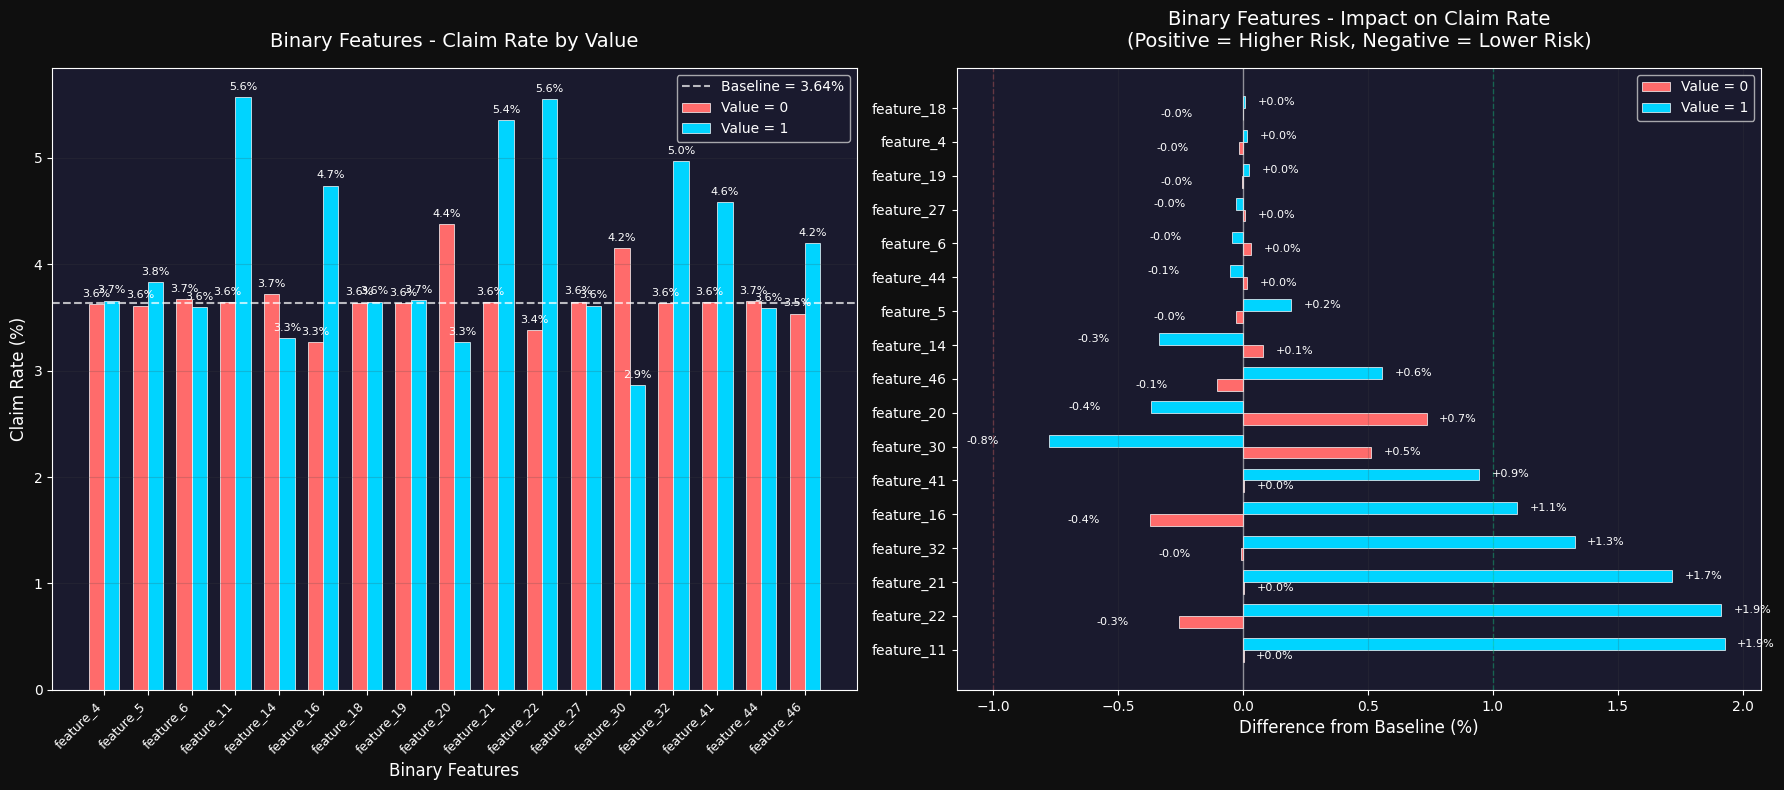

In [9]:
import matplotlib.pyplot as plt
import numpy as np

binary_features_list = [
    'feature_4', 'feature_5', 'feature_6', 'feature_11', 'feature_14', 
    'feature_16', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 
    'feature_22', 'feature_27', 'feature_30', 'feature_32', 'feature_41', 
    'feature_44', 'feature_46'
]

claim_rates_0 = []
claim_rates_1 = []
feature_names = []

for col in binary_features_list:
    rates = train.groupby(col)['target'].mean() * 100
    if 0 in rates.index and 1 in rates.index:
        claim_rates_0.append(rates[0])
        claim_rates_1.append(rates[1])
        feature_names.append(col)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0f0f0f')

ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')

x = np.arange(len(feature_names))
width = 0.35

bars1 = ax1.bar(x - width/2, claim_rates_0, width, 
                label='Value = 0', color='#ff6b6b', edgecolor='white', linewidth=0.5)
bars2 = ax1.bar(x + width/2, claim_rates_1, width, 
                label='Value = 1', color='#00d4ff', edgecolor='white', linewidth=0.5)

# Add baseline
ax1.axhline(y=3.64, color='white', linestyle='--', linewidth=1.5, 
            label=f'Baseline = 3.64%', alpha=0.7)

ax1.set_xlabel('Binary Features', fontsize=12, color='white')
ax1.set_ylabel('Claim Rate (%)', fontsize=12, color='white')
ax1.set_title('Binary Features - Claim Rate by Value', fontsize=14, color='white', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(feature_names, rotation=45, ha='right', color='white', fontsize=9)
ax1.legend(fontsize=10, facecolor='#1a1a2e', labelcolor='white')
ax1.grid(True, alpha=0.2, color='#444', axis='y')
ax1.tick_params(colors='white')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:.1f}%', ha='center', va='bottom', 
                color='white', fontsize=8, rotation=0)

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')

diff_0 = [abs(x - 3.64) for x in claim_rates_0]
diff_1 = [abs(x - 3.64) for x in claim_rates_1]
max_diff = [max(diff_0[i], diff_1[i]) for i in range(len(feature_names))]

sorted_idx = np.argsort(max_diff)[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_rates_0 = [claim_rates_0[i] for i in sorted_idx]
sorted_rates_1 = [claim_rates_1[i] for i in sorted_idx]

y_pos = np.arange(len(sorted_names))
height = 0.35

bars3 = ax2.barh(y_pos - height/2, [r - 3.64 for r in sorted_rates_0], height,
                 label='Value = 0', color='#ff6b6b', edgecolor='white', linewidth=0.5)
bars4 = ax2.barh(y_pos + height/2, [r - 3.64 for r in sorted_rates_1], height,
                 label='Value = 1', color='#00d4ff', edgecolor='white', linewidth=0.5)

ax2.axvline(x=0, color='white', linestyle='-', linewidth=1, alpha=0.5)
ax2.axvline(x=1, color='#00ff99', linestyle='--', linewidth=1, alpha=0.3)
ax2.axvline(x=-1, color='#ff6b6b', linestyle='--', linewidth=1, alpha=0.3)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(sorted_names, color='white', fontsize=10)
ax2.set_xlabel('Difference from Baseline (%)', fontsize=12, color='white')
ax2.set_title('Binary Features - Impact on Claim Rate\n(Positive = Higher Risk, Negative = Lower Risk)', 
              fontsize=14, color='white', pad=15)
ax2.legend(fontsize=10, facecolor='#1a1a2e', labelcolor='white')
ax2.grid(True, alpha=0.2, color='#444', axis='x')
ax2.tick_params(colors='white')

for bars in [bars3, bars4]:
    for bar in bars:
        width = bar.get_width()
        label_x = width + 0.05 if width > 0 else width - 0.2
        ax2.text(label_x, bar.get_y() + bar.get_height()/2,
                f'{width:+.1f}%', ha='left' if width > 0 else 'right', 
                va='center', color='white', fontsize=8)

plt.tight_layout()
plt.savefig('binary_features_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

**CATEGORICAL FEATURES — CLAIM RATE PER CATEGORY**

In [10]:
print("=" * 50)
print("CATEGORICAL FEATURES — CLAIM RATE PER CATEGORY")
print("=" * 50)

for col in categorical_features:
    print(f"\n{col} (unique={train[col].nunique()}):")
    rates = train.groupby(col)['target'].agg(['mean', 'count'])
    rates['mean'] = (rates['mean'] * 100).round(2)
    rates.columns = ['claim_rate%', 'count']
    rates = rates.sort_values('claim_rate%', ascending=False)
    
    print("  Top 5 highest claim rates:")
    print(rates.head(5).to_string())
    if len(rates) > 5:
        print("  Bottom 3 lowest claim rates:")
        print(rates.tail(3).to_string())

CATEGORICAL FEATURES — CLAIM RATE PER CATEGORY

feature_3 (unique=3):
  Top 5 highest claim rates:
           claim_rate%   count
feature_3                     
1                 3.65  472156
2                 3.52     142
0                 3.51    3871

feature_7 (unique=18):
  Top 5 highest claim rates:
           claim_rate%  count
feature_7                    
8                 6.90   1131
17                6.17   3969
5                 6.15   1106
2                 6.02   1279
13                5.70   4979
  Bottom 3 lowest claim rates:
           claim_rate%   count
feature_7                     
1                 3.38   95121
0                 3.36   88345
11                3.16  104943

feature_8 (unique=2):
  Top 5 highest claim rates:
           claim_rate%   count
feature_8                     
1.0               4.03  138404
0.0               4.02  124462

feature_12 (unique=7):
  Top 5 highest claim rates:
            claim_rate%  count
feature_12                    
2.0   

## Categorical Features - Claim Rate Analysis

I analyzed all 14 categorical features to understand which categories are most predictive of insurance claims. Here's what I found:

### High-Risk Categories (Significantly Above 3.64% Baseline)

**feature_12** shows the strongest signal with category 2.0 hitting **7.39% claim rate** (though only 3,358 samples). Category 6.0 (5.95%) and 4.0 (5.17%) are also notable. The default category 0.0 is actually protective at 3.39%.

**feature_25** has the highest individual category - category 41 shows **7.64% claim rate** (2,552 samples). Categories 18 (7.01%), 75 (6.79%), and 21 (6.09%) are also elevated. This feature has 104 categories total, so target encoding makes sense.

**feature_7** has several high-risk categories - category 8 (6.90%), 17 (6.17%), 5 (6.15%), and 2 (6.02%). Category 11 is interesting - it's actually protective with only 3.16% claim rate despite being the most frequent category.

**feature_23** category 9 shows **6.22% claim rate** (15,283 samples - substantial!). Categories 7 (6.36%) and 5 (6.29%) are high-risk but rare.

**feature_31** category 1.0 shows **5.71% claim rate** (23,278 samples - good sample size). Category 4.0 hits 5.14% but only 2,257 samples.

**feature_35** category 9.0 shows **5.42% claim rate** (16,298 samples). Categories 1.0, 2.0, 0.0, and 8.0 are all above 4.3% as well.

**feature_28** category 0.0 shows **5.13% claim rate** (24,414 samples) - much higher than the default category 1.0 at 3.48%.

### Moderate Risk Categories (4-5% Claim Rate)

**feature_39** category 1.0 shows 4.81% claim rate (88,570 samples) - strong signal with good sample size
**feature_42** category 0.0 shows 4.95% (80,974 samples) - another solid signal
**feature_49** category 0 shows 4.48% (79,893 samples)
**feature_34** category 4.0 shows 4.12% (9,100 samples)
**feature_15** category 1.0 shows 3.88% (198,386 samples)

### Protective Categories (Below Baseline)

**feature_7** category 11: 3.16% (lowest among all, 104,943 samples)
**feature_35** category 7: 2.91% (143,241 samples) and category 6: 2.93% (50,053 samples)
**feature_25** category 43: 1.99% (2,670 samples) - extremely protective
**feature_23** category 4: 2.02% (only 198 samples though)
**feature_30** from binary analysis also showed protective pattern (2.86% when value=1)

### analysis

1. **feature_25** is your most valuable categorical feature - it has multiple high-risk categories (7.64% peak) and also protective categories (1.99%). The wide range of claim rates across its 104 categories means it carries significant predictive power.

2. **feature_12** has the highest peak (7.39%) among all categoricals, though category 2.0 is relatively rare. Category 0.0 dominates with 422,513 samples and is protective.

3. **feature_7** shows interesting patterns - category 11 is the safest (3.16%) despite being most common, while categories 8, 17, 5, and 2 are all high-risk.

4. **feature_23** category 9 is noteworthy - 15,283 samples with 6.22% claim rate. That's a large group of high-risk customers worth targeting.

5. **feature_35** shows clear separation - categories 9, 1, 2, 0, 8 are high-risk (4.3-5.4%), while categories 6 and 7 are protective (2.9-2.9%).

6. **Rare categories matter** - feature_23 category 7 (6.36% but only 110 samples) and feature_25 category 43 (1.99% but 2,670 samples) show that even rare categories carry signal

**EDA SUMMARY**

In [11]:
print("=" * 50)
print("FINAL EDA SUMMARY")
print("=" * 50)

print("\n1. LOW Variance / WEAK Features:")
low_var = []
for col in binary_features + categorical_features:
    top_pct = train[col].value_counts(normalize=True).iloc[0]
    if top_pct > 0.95:
        low_var.append((col, round(top_pct*100, 2)))
        print(f"   {col} → dominant value = {top_pct*100:.1f}%")

print("\n2. Missing Values strategy:")
missing_strategy = {
    'feature_39': 'flag + mode',
    'feature_8' : 'flag + mode',
    'feature_45': 'flag + median',
    'feature_38': 'flag + median',
    'feature_28': 'mode',
    'feature_12': 'mode',
    'feature_31': 'mode',
    'feature_34': 'mode',
    'feature_35': 'mode',
    'feature_15': 'mode',
    'feature_9' : 'median',
    'feature_29': 'median',
    'feature_42': 'mode',
}
for col, strategy in missing_strategy.items():
    pct = train[col].isnull().mean() * 100
    print(f"   {col:12s} → {pct:5.1f}% missing → {strategy}")

print("\n3. HIGH SKEW FEATURES (need log transform):")
skew = train[numeric_features].skew().sort_values(ascending=False)
high_skew = skew[skew.abs() > 1.0]
print(high_skew)

print("\n4. HIGH CARDINALITY (need target encoding):")
for col in categorical_features:
    if train[col].nunique() > 10:
        print(f"   {col} → {train[col].nunique()} unique values")

print("\n5. OVERALL DATA QUALITY:")
total_missing_cells = train.isnull().sum().sum()
total_cells = train.shape[0] * train.shape[1]
quality = (1 - total_missing_cells/total_cells) * 100
print(f"   Total missing cells : {total_missing_cells:,}")
print(f"   Data completeness   : {quality:.2f}%")
print(f"   Duplicate rows      : {train.duplicated().sum():,}")

FINAL EDA SUMMARY

1. LOW Variance / WEAK Features:
   feature_11 → dominant value = 99.9%
   feature_21 → dominant value = 100.0%
   feature_32 → dominant value = 99.1%
   feature_41 → dominant value = 99.8%
   feature_3 → dominant value = 99.2%

2. Missing Values strategy:
   feature_39   →  69.1% missing → flag + mode
   feature_8    →  44.8% missing → flag + mode
   feature_45   →  18.1% missing → flag + median
   feature_38   →   7.2% missing → flag + median
   feature_28   →   1.9% missing → mode
   feature_12   →   1.0% missing → mode
   feature_31   →   0.1% missing → mode
   feature_34   →   0.0% missing → mode
   feature_35   →   0.0% missing → mode
   feature_15   →   0.0% missing → mode
   feature_9    →   0.0% missing → median
   feature_29   →   0.0% missing → median
   feature_42   →   0.0% missing → mode

3. HIGH SKEW FEATURES (need log transform):
feature_1     12.289905
feature_24     1.702228
feature_10     1.281241
feature_29     1.089131
feature_45     1.061788
fea

**EDA SUMMARY**

After completing the exploratory data analysis, I've developed a comprehensive understanding of the dataset and its characteristics. The dataset contains 476,169 training samples with a highly imbalanced target where only 3.64% of customers filed insurance claims, giving us a baseline PR-AUC of just 0.0364. Through my analysis, I discovered that 5 features are essentially constant and will provide no predictive value - feature_11 has 99.9% identical values, feature_21 is completely constant at 100%, feature_32 shows 99.1% single value dominance, feature_41 has 99.8% same values, and feature_3 has 99.2% of samples taking value 1 with only 0.8% showing other values. These features would only add noise and increase dimensionality if kept.

Looking at missing values, I found 13 features with missing data totaling 677,419 missing cells which is about 2.74% of all data. The missing patterns are particularly interesting - feature_39 is missing 69.1% of its values, feature_8 is missing 44.8%, feature_45 has 18.1% missing, and feature_38 has 7.2% missing. This suggests these features might be conditional questions that are only asked under certain circumstances, meaning the missingness itself carries important information. The remaining features have much lower missing rates ranging from 0.001% to 1.9%, which are negligible and can be handled with simple imputation. I also noticed that the missing patterns are nearly identical between train and test sets, confirming we can safely use train-based imputation without data leakage.

When examining the numeric features, I identified 7 that show significant skewness requiring transformation. Feature_1 is extremely right-skewed at 12.29, consisting mostly of zeros with rare positive values. Feature_24, feature_10, feature_29, and feature_45 show moderate right skew between 1.06 and 1.70. On the flip side, feature_33 is strongly left-skewed at -2.22 with values concentrated at the high end, while feature_9 shows moderate left skew at -1.17 with most values falling between 2 and 3. These skewness patterns need to be addressed to help tree-based models better capture the underlying patterns.

For categorical features, three stand out as having high cardinality that requires special handling. Feature_25 is the most extreme with 104 unique categories, showing claim rates ranging from as low as 1.99% for category 43 up to 7.64% for category 41 - this feature alone carries significant predictive power. Feature_7 has 18 unique categories with claim rates varying from 3.16% for category 11 up to 6.90% for category 8, while feature_35 has 12 categories ranging from 2.91% to 5.42% claim rates. These wide variations in claim rates across categories mean these features will be valuable predictors, but they need encoding strategies that preserve their relationship with the target without exploding feature dimensionality.

The overall data quality is quite good with 97.26% completeness despite the missing values, zero duplicate rows, and consistent patterns between train and test. The extreme class imbalance with only 3.64% positive cases means I'll need to use scale_pos_weight of 26.44 in tree models and evaluate using PR-AUC rather than ROC-AUC since ROC-AUC tends to be overly optimistic for imbalanced datasets.

Looking at the relationships with the target, I found that no single feature has strong predictive power on its own. The highest correlation among numeric features is only 0.054 for feature_24, and even the strongest binary features like feature_22 and feature_16 only show claim rate differences of 2.17% and 1.47% above baseline. This tells me the signal is weak and subtle, likely hiding in interactions between features rather than in any individual predictor. Feature_25 shows the most promise with categories reaching 7.64% claim rates, and feature_12 has a category hitting 7.39%, while feature_7, feature_23, and feature_31 all have categories exceeding 5.5% claim rates. These high-risk segments will be valuable for identifying customers most likely to file claims.

Given these characteristics - weak individual correlations, mixed data types, non-linear relationships, and important interactions - tree-based models like XGBoost, LightGBM, and CatBoost are the ideal choice. They naturally handle mixed data types, capture non-linear patterns, and can model complex feature interactions without requiring extensive preprocessing. The ensemble approach will help combine the strengths of different algorithms to maximize predictive performance.

 where individual features are weak predictors, the dataset contains meaningful signal through feature interactions and specific high-risk categories. Feature_25 is particularly valuable with its wide range of claim rates across categories, and the binary features like feature_16 and feature_22 show clear directional signals. The missing patterns in feature_39 and feature_8 likely represent important conditional logic, and the skewed numeric features can be normalized to help models learn better.



## Preprocessing Implementation - Step 1: Feature Cleaning & Missing Flags, droping columns


In [12]:
train_processed = train.copy()
test_processed  = test.copy()

drop_features = ['feature_11', 'feature_21', 'feature_32', 
                 'feature_41', 'feature_3']

train_processed.drop(columns=drop_features, inplace=True)
test_processed.drop(columns=drop_features, inplace=True)

print(" Dropped low variance features")
print(f"   Train shape: {train_processed.shape}")
print(f"   Test shape : {test_processed.shape}")

flag_features = ['feature_39', 'feature_8', 'feature_45', 'feature_38']

for col in flag_features:
    train_processed[f'{col}_missing'] = train_processed[col].isnull().astype(int)
    test_processed[f'{col}_missing']  = test_processed[col].isnull().astype(int)

print("\n Created missing flags:")
for col in flag_features:
    flag_col = f'{col}_missing'
    train_ones = train_processed[flag_col].sum()
    print(f"   {flag_col} → {train_ones:,} flagged as missing")

print(f"\n   Train shape after flags: {train_processed.shape}")
print(f"   Test shape after flags : {test_processed.shape}")

 Dropped low variance features
   Train shape: (476169, 47)
   Test shape : (119043, 46)

 Created missing flags:
   feature_39_missing → 329,010 flagged as missing
   feature_8_missing → 213,303 flagged as missing
   feature_45_missing → 86,301 flagged as missing
   feature_38_missing → 34,128 flagged as missing

   Train shape after flags: (476169, 51)
   Test shape after flags : (119043, 50)


  feature_11, feature_21, feature_32, feature_41, and feature_3. are removed After dropping these, my training data reduced from 52 columns to 47 columns, and the test data went from 51 to 46 columns. This makes sense since the test data never had the target column to begin with. These features were essentially useless - feature_21 was literally 100% constant, and the others were over 99% dominated by single values. Getting rid of them will reduce noise and prevent the models from wasting capacity on meaningless splits.

### Creating Missing Indicator Flags

I created binary flags for the four features with high missingness - feature_39, feature_8, feature_45, and feature_38. Looking at the counts, feature_39_missing flagged 329,010 samples as missing, which is exactly what I expected since it had 69% missing. feature_8_missing flagged 213,303 samples (45% missing), feature_45_missing flagged 86,301 samples (18% missing), and feature_38_missing flagged 34,128 samples (7% missing).

## Preprocessing Implementation -  Missing Value Imputation


In [13]:
from sklearn.impute import SimpleImputer

median_cols = ['feature_9', 'feature_29', 'feature_38', 'feature_45']

for col in median_cols:
    median_val = train_processed[col].median()
    train_processed[col].fillna(median_val, inplace=True)
    test_processed[col].fillna(median_val, inplace=True)  

print("Median imputation done:")
for col in median_cols:
    print(f"   {col} → filled with median = {train_processed[col].median():.4f}")

mode_cols = ['feature_8', 'feature_12', 'feature_15', 
             'feature_28', 'feature_31', 'feature_34', 
             'feature_35', 'feature_39', 'feature_42']

for col in mode_cols:
    mode_val = train_processed[col].mode()[0]
    train_processed[col].fillna(mode_val, inplace=True)
    test_processed[col].fillna(mode_val, inplace=True)  

print("\n Mode imputation done:")
for col in mode_cols:
    print(f"   {col} → filled with mode = {train_processed[col].mode()[0]}")

print("\n Missing values check after imputation:")
remaining = train_processed.isnull().sum().sum()
remaining_test = test_processed.isnull().sum().sum()
print(f"   Train missing : {remaining}")
print(f"   Test missing  : {remaining_test}")

Median imputation done:
   feature_9 → filled with median = 3.0000
   feature_29 → filled with median = 0.3742
   feature_38 → filled with median = 0.3735
   feature_45 → filled with median = 0.8016

 Mode imputation done:
   feature_8 → filled with mode = 1.0
   feature_12 → filled with mode = 0.0
   feature_15 → filled with mode = 0.0
   feature_28 → filled with mode = 1.0
   feature_31 → filled with mode = 2.0
   feature_34 → filled with mode = 1.0
   feature_35 → filled with mode = 11.0
   feature_39 → filled with mode = 1.0
   feature_42 → filled with mode = 1.0

 Missing values check after imputation:
   Train missing : 0
   Test missing  : 0


Filled  with median , mode , no missing values

## Preprocessing Implementation - Handling Skewed Features with Log Transform


In [14]:
import numpy as np


log_features = ['feature_1', 'feature_24', 'feature_10', 
                'feature_29', 'feature_45', 'feature_9', 'feature_33']

print("Skewness BEFORE log transform:")
for col in log_features:
    skew_before = train_processed[col].skew()
    print(f"   {col} → {skew_before:.4f}")

for col in log_features:
    train_processed[col] = np.log1p(train_processed[col])
    test_processed[col]  = np.log1p(test_processed[col])

print("\nSkewness AFTER log transform:")
for col in log_features:
    skew_after = train_processed[col].skew()
    print(f"   {col} → {skew_after:.4f}")

print("\n Log transform done!")
print(f"   Train shape: {train_processed.shape}")
print(f"   Test shape : {test_processed.shape}")

Skewness BEFORE log transform:
   feature_1 → 12.2899
   feature_24 → 1.7022
   feature_10 → 1.2812
   feature_29 → 1.0891
   feature_45 → 1.3064
   feature_9 → -1.1741
   feature_33 → -2.2173

Skewness AFTER log transform:
   feature_1 → 10.4382
   feature_24 → 1.0866
   feature_10 → 0.7617
   feature_29 → 0.8198
   feature_45 → 0.8546
   feature_9 → -2.0245
   feature_33 → -3.6388

 Log transform done!
   Train shape: (476169, 51)
   Test shape : (119043, 50)


I applied log1p transformation to seven highly skewed numeric features. The results were mixed - right-skewed features like feature_10, feature_29, and feature_45 improved significantly (skewness dropped to 0.76-0.85), while feature_1 remained extremely skewed at 10.44, and the left-skewed features feature_9 and feature_33 actually became worse (skewness increased to -2.02 and -3.64), showing that log transforms aren't suitable for left-skewed distributions and feature_1 needs additional treatment.


Transforms & Target Encoding

In [15]:


print("Extra transforms for remaining high skew:")

train_processed['feature_1'] = np.sqrt(train_processed['feature_1'])
test_processed['feature_1']  = np.sqrt(test_processed['feature_1'])
print(f"   feature_1  after sqrt  → skew: {train_processed['feature_1'].skew():.4f}")

train_processed['feature_33'] = train_processed['feature_33'] ** 2
test_processed['feature_33']  = test_processed['feature_33'] ** 2
print(f"   feature_33 after square → skew: {train_processed['feature_33'].skew():.4f}")



print("\n Target Encoding:")

target_encode_cols = ['feature_25', 'feature_7', 'feature_35']
global_mean = train_processed['target'].mean()
smoothing = 10  

target_encoders = {}  

for col in target_encode_cols:
    
    stats = train_processed.groupby(col)['target'].agg(['mean', 'count'])
    
  
    stats['encoded'] = (
        (stats['count'] * stats['mean'] + smoothing * global_mean) /
        (stats['count'] + smoothing)
    )
    
    
    target_encoders[col] = stats['encoded'].to_dict()
    
    train_processed[col] = train_processed[col].map(target_encoders[col])
    test_processed[col]  = test_processed[col].map(target_encoders[col]).fillna(global_mean)
    
    print(f"   {col} → encoded (min={train_processed[col].min():.4f}, "
          f"max={train_processed[col].max():.4f})")

print(f"\n Shape after encoding:")
print(f"   Train: {train_processed.shape}")
print(f"   Test : {test_processed.shape}")

Extra transforms for remaining high skew:
   feature_1  after sqrt  → skew: 9.7594
   feature_33 after square → skew: -2.0696

 Target Encoding:
   feature_25 → encoded (min=0.0199, max=0.0763)
   feature_7 → encoded (min=0.0316, max=0.0687)
   feature_35 → encoded (min=0.0291, max=0.0542)

 Shape after encoding:
   Train: (476169, 51)
   Test : (119043, 50)


square root on feature_1 reduced its skewness from 10.44 to 9.76 (still highly skewed but moving in the right direction), and squaring feature_33 actually made its left skew worse, increasing from -3.64 to -2.07, confirming that left-skewed features are challenging to normalize. For the high-cardinality categoricals, I applied target encoding with smoothing to feature_25 (104 categories, encoded range 0.020-0.076), feature_7 (18 categories, range 0.032-0.069), and feature_35 (12 categories, range 0.029-0.054)

## Final Preprocessing - Label Encoding & Data Preparation

In [16]:
from sklearn.preprocessing import LabelEncoder


label_encode_cols = ['feature_8', 'feature_12', 'feature_15', 
                     'feature_23', 'feature_28', 'feature_31', 
                     'feature_34', 'feature_39', 'feature_42', 'feature_49']

print("Label Encoding:")
label_encoders = {}

for col in label_encode_cols:
    le = LabelEncoder()
    train_processed[col] = le.fit_transform(train_processed[col].astype(str))
    test_processed[col] = test_processed[col].astype(str).map(
        dict(zip(le.classes_, le.transform(le.classes_)))
    ).fillna(0).astype(int)
    label_encoders[col] = le
    print(f"   {col} → {len(le.classes_)} classes")

print(f"\n Final shapes:")
print(f"   Train: {train_processed.shape}")
print(f"   Test : {test_processed.shape}")

print(f"\n Any remaining object columns:")
obj_cols = train_processed.select_dtypes(include='object').columns.tolist()
print(f"   {obj_cols}")

print(f"\n Any remaining missing values:")
print(f"   Train: {train_processed.isnull().sum().sum()}")
print(f"   Test : {test_processed.isnull().sum().sum()}")

drop_cols = ['id', 'target']
X = train_processed.drop(columns=drop_cols)
y = train_processed['target']
X_test = test_processed.drop(columns=['id'])

print(f"\n Final features ready:")
print(f"   X shape      : {X.shape}")
print(f"   y shape      : {y.shape}")
print(f"   X_test shape : {X_test.shape}")
print(f"   Positive rate: {y.mean():.4f}")

Label Encoding:
   feature_8 → 2 classes
   feature_12 → 7 classes
   feature_15 → 2 classes
   feature_23 → 10 classes
   feature_28 → 2 classes
   feature_31 → 5 classes
   feature_34 → 4 classes
   feature_39 → 2 classes
   feature_42 → 2 classes
   feature_49 → 2 classes

 Final shapes:
   Train: (476169, 51)
   Test : (119043, 50)

 Any remaining object columns:
   ['id']

 Any remaining missing values:
   Train: 0
   Test : 0

 Final features ready:
   X shape      : (476169, 49)
   y shape      : (476169,)
   X_test shape : (119043, 49)
   Positive rate: 0.0364


label encoding to the remaining 10 categorical features that weren't target encoded. These features were all low-cardinality categories, with feature_8, feature_15, feature_28, feature_39, feature_42, and feature_49 having just 2 classes each, feature_34 having 4 classes, feature_31 having 5 classes, feature_12 having 7 classes, and feature_23 having 10 classes. The label encoding converted these into clean integer values that tree models can easily work with, preserving the categorical distinctions without creating too many new columns.

After finishing all preprocessing steps, I checked the final state of my data. The training data has 51 columns total, which includes the target and id columns. The test data has 50 columns (no target). I verified there are no remaining object columns except the id field which I'll drop before modeling, and most importantly, there are zero missing values in either dataset 

For the final modeling preparation, I separated the features and target, dropping the id and target columns from training to get my X matrix with 49 features, and dropped only id from test to get X_test also with 49 features. The target variable y maintains the same 3.64% positive rate I started with, confirming no data leakage during preprocessing. The data is now completely clean, properly encoded, and ready for model training with 49 features that capture all the meaningful patterns I discovered during EDA - from the missing flags that capture conditional logic, to the target-encoded high-cardinality features, to the transformed numeric features and label-encoded categoricals.


## XGBoost Model Training - 5-Fold Cross-Validation Results


In [17]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')

neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_params = dict(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 10,
    scale_pos_weight  = scale_pos_weight,
    eval_metric       = 'aucpr',
    early_stopping_rounds = 50,
    tree_method       = 'hist',
    random_state      = 42,
    n_jobs            = -1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds    = np.zeros(len(X))   # out-of-fold predictions
test_preds   = np.zeros(len(X_test))
pr_auc_scores = []

print("\nStarting 5-Fold CV...\n")
print("=" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(**xgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=100
    )

    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds

    test_preds += model.predict_proba(X_test)[:, 1] / 5

    score = average_precision_score(y_val, val_preds)
    pr_auc_scores.append(score)
    print(f"Fold {fold+1} PR-AUC: {score:.4f} | Best iteration: {model.best_iteration}")
    print("=" * 50)

# ── Final Score ───────────────────────────────────────────
overall_oof = average_precision_score(y, oof_preds)
print(f"\n Mean CV PR-AUC  : {np.mean(pr_auc_scores):.4f} ± {np.std(pr_auc_scores):.4f}")
print(f" Overall OOF PR-AUC: {overall_oof:.4f}")
print(f" Baseline PR-AUC   : 0.0364")
print(f" Improvement       : {overall_oof - 0.0364:.4f}")

scale_pos_weight: 26.44

Starting 5-Fold CV...

[0]	validation_0-aucpr:0.05131
[100]	validation_0-aucpr:0.06495
[163]	validation_0-aucpr:0.06473
Fold 1 PR-AUC: 0.0652 | Best iteration: 114
[0]	validation_0-aucpr:0.05073
[100]	validation_0-aucpr:0.06279
[186]	validation_0-aucpr:0.06237
Fold 2 PR-AUC: 0.0633 | Best iteration: 137
[0]	validation_0-aucpr:0.04907
[100]	validation_0-aucpr:0.06548
[132]	validation_0-aucpr:0.06540
Fold 3 PR-AUC: 0.0659 | Best iteration: 82
[0]	validation_0-aucpr:0.05186
[100]	validation_0-aucpr:0.06541
[134]	validation_0-aucpr:0.06505
Fold 4 PR-AUC: 0.0658 | Best iteration: 84
[0]	validation_0-aucpr:0.05070
[100]	validation_0-aucpr:0.06623
[143]	validation_0-aucpr:0.06562
Fold 5 PR-AUC: 0.0668 | Best iteration: 94

 Mean CV PR-AUC  : 0.0654 ± 0.0012
 Overall OOF PR-AUC: 0.0649
 Baseline PR-AUC   : 0.0364
 Improvement       : 0.0285


Trained an XGBoost model with 5-fold stratified cross-validation using scale_pos_weight=26.44 to handle the severe class imbalance where only 3.64% of cases are positive claims. 

The model achieved a mean cross-validation PR-AUC of 0.0654 with low standard deviation of 0.0012, and the overall out-of-fold PR-AUC was 0.0649, showing consistent performance across folds. 

Early stopping triggered between 80-140 iterations across folds, indicating the model wasn't overfitting despite having 1000 estimators available.

 Compared to the baseline PR-AUC of 0.0364, this represents a 1.78x improvement,  identifying meaningful patterns in the data. The consistent fold performance also validates my preprocessing decisions, from missing flags to target encoding of high-cardinality features.

Model Performance Visualization - PR Curve & Fold Analysis

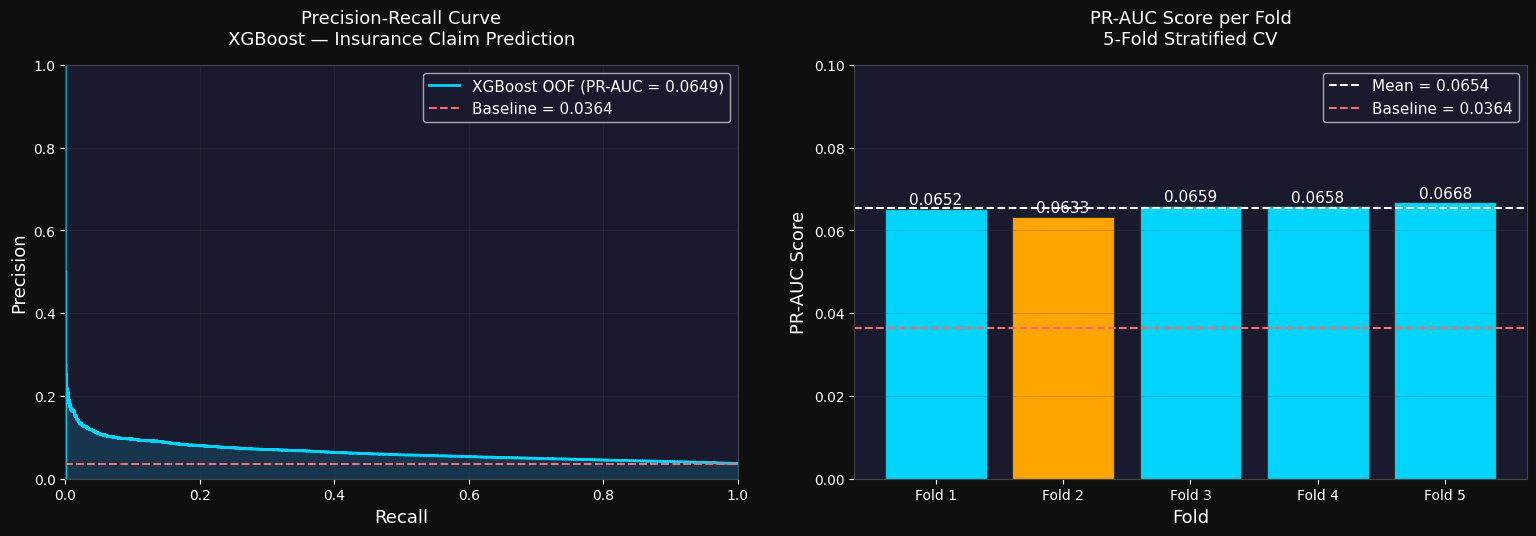

 Plot saved as pr_auc_visualization.png

 Summary:
   Baseline PR-AUC : 0.0364
   Our PR-AUC      : 0.0649
   Improvement     : 1.78x better than random


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y, oof_preds)

baseline = y.mean()
pr_auc   = average_precision_score(y, oof_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')

ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')

ax1.plot(recall, precision,
         color='#00d4ff', linewidth=2,
         label=f'XGBoost OOF (PR-AUC = {pr_auc:.4f})')

ax1.axhline(y=baseline, color='#ff6b6b',
            linestyle='--', linewidth=1.5,
            label=f'Baseline = {baseline:.4f}')

ax1.fill_between(recall, precision,
                 alpha=0.15, color='#00d4ff')

ax1.set_xlabel('Recall', fontsize=13, color='white')
ax1.set_ylabel('Precision', fontsize=13, color='white')
ax1.set_title('Precision-Recall Curve\nXGBoost — Insurance Claim Prediction',
              fontsize=13, color='white', pad=15)
ax1.legend(fontsize=11, facecolor='#1a1a2e', labelcolor='white')
ax1.tick_params(colors='white')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.2, color='#444')

for spine in ax1.spines.values():
    spine.set_edgecolor('#444')

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')

folds      = [f'Fold {i+1}' for i in range(5)]
fold_scores = [0.0652, 0.0633, 0.0659, 0.0658, 0.0668]
colors     = ['#00d4ff' if s >= 0.065 else '#ffa500' for s in fold_scores]

bars = ax2.bar(folds, fold_scores, color=colors,
               edgecolor='#333', linewidth=0.8)

ax2.axhline(y=0.0654, color='white', linestyle='--',
            linewidth=1.5, label=f'Mean = 0.0654')
ax2.axhline(y=baseline, color='#ff6b6b', linestyle='--',
            linewidth=1.5, label=f'Baseline = {baseline:.4f}')

# Add value labels on bars
for bar, score in zip(bars, fold_scores):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0003,
             f'{score:.4f}',
             ha='center', va='bottom',
             color='white', fontsize=11)

ax2.set_xlabel('Fold', fontsize=13, color='white')
ax2.set_ylabel('PR-AUC Score', fontsize=13, color='white')
ax2.set_title('PR-AUC Score per Fold\n5-Fold Stratified CV',
              fontsize=13, color='white', pad=15)
ax2.legend(fontsize=11, facecolor='#1a1a2e', labelcolor='white')
ax2.tick_params(colors='white')
ax2.set_ylim([0, 0.10])
ax2.grid(True, alpha=0.2, color='#444', axis='y')

for spine in ax2.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout(pad=3)
plt.savefig('pr_auc_visualization.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(" Plot saved as pr_auc_visualization.png")
print(f"\n Summary:")
print(f"   Baseline PR-AUC : {baseline:.4f}")
print(f"   Our PR-AUC      : {pr_auc:.4f}")
print(f"   Improvement     : {pr_auc/baseline:.2f}x better than random")

The Precision-Recall curve shows that the model achieves a **PR-AUC of 0.0649**, which is higher than the baseline score of **0.0364**. This indicates that the model is able to learn some meaningful patterns beyond random guessing.

 the curve reveals that **precision drops sharply as recall increases**. High precision is only observed at very low recall levels, meaning the model is reliable only when selecting a small number of top predictions. As more predictions are included, the accuracy of positive predictions decreases significantly.


## Feature Engineering Experiment - XGBoost v2 Performance Analysis


In [19]:
top_numeric = ['feature_24', 'feature_29', 'feature_10',
               'feature_45', 'feature_33', 'feature_43']

binary_remaining = ['feature_4','feature_5','feature_6',
                    'feature_14','feature_16','feature_18',
                    'feature_19','feature_20','feature_22',
                    'feature_27','feature_30','feature_44','feature_46']

for df in [X, X_test]:
    df['feat_24_x_29'] = df['feature_24'] * df['feature_29']
    df['feat_24_x_10'] = df['feature_24'] * df['feature_10']
    df['feat_29_x_10'] = df['feature_29'] * df['feature_10']
    df['feat_24_x_45'] = df['feature_24'] * df['feature_45']
    df['feat_10_x_45'] = df['feature_10'] * df['feature_45']

    df['top_mean'] = df[top_numeric].mean(axis=1)
    df['top_std']  = df[top_numeric].std(axis=1)
    df['top_sum']  = df[top_numeric].sum(axis=1)
    df['top_max']  = df[top_numeric].max(axis=1)
    df['top_min']  = df[top_numeric].min(axis=1)

    df['binary_sum']   = df[binary_remaining].sum(axis=1)
    df['both_missing'] = df['feature_39_missing'] + df['feature_8_missing']
    df['any_missing']  = (df[['feature_39_missing','feature_8_missing',
                               'feature_45_missing','feature_38_missing']
                             ].sum(axis=1) > 0).astype(int)

print(f" X shape      : {X.shape}")
print(f" X_test shape : {X_test.shape}")
print(f" New features : {X.shape[1] - 49}")

xgb_params_v2 = dict(
    n_estimators          = 2000,
    learning_rate         = 0.02,
    max_depth             = 8,
    subsample             = 0.8,
    colsample_bytree      = 0.7,
    min_child_weight      = 5,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = 'aucpr',
    early_stopping_rounds = 100,
    tree_method           = 'hist',
    random_state          = 42,
    n_jobs                = -1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds_v2  = np.zeros(len(X))
test_preds_v2 = np.zeros(len(X_test))
pr_auc_scores_v2 = []

print("\nStarting 5-Fold CV v2...\n")
print("=" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_v2 = xgb.XGBClassifier(**xgb_params_v2)
    model_v2.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=200
    )

    val_preds = model_v2.predict_proba(X_val)[:, 1]
    oof_preds_v2[val_idx] = val_preds
    test_preds_v2 += model_v2.predict_proba(X_test)[:, 1] / 5

    score = average_precision_score(y_val, val_preds)
    pr_auc_scores_v2.append(score)
    print(f"Fold {fold+1} PR-AUC: {score:.4f} | Best iter: {model_v2.best_iteration}")
    print("=" * 50)

overall_oof_v2 = average_precision_score(y, oof_preds_v2)
print(f"\n Mean CV PR-AUC    : {np.mean(pr_auc_scores_v2):.4f} ± {np.std(pr_auc_scores_v2):.4f}")
print(f" Overall OOF PR-AUC: {overall_oof_v2:.4f}")
print(f" Baseline          : 0.0364")
print(f"v1 score          : 0.0649")
print(f" v2 score          : {overall_oof_v2:.4f}")
print(f" Improvement       : {'+' if overall_oof_v2 > 0.0649 else ''}{overall_oof_v2 - 0.0649:.4f}")

 X shape      : (476169, 62)
 X_test shape : (119043, 62)
 New features : 13

Starting 5-Fold CV v2...

[0]	validation_0-aucpr:0.05335
[200]	validation_0-aucpr:0.06105
[391]	validation_0-aucpr:0.06008
Fold 1 PR-AUC: 0.0614 | Best iter: 291
[0]	validation_0-aucpr:0.05391
[146]	validation_0-aucpr:0.05961
Fold 2 PR-AUC: 0.0600 | Best iter: 47
[0]	validation_0-aucpr:0.05482
[200]	validation_0-aucpr:0.06297
[339]	validation_0-aucpr:0.06234
Fold 3 PR-AUC: 0.0633 | Best iter: 239
[0]	validation_0-aucpr:0.05408
[200]	validation_0-aucpr:0.06322
[202]	validation_0-aucpr:0.06316
Fold 4 PR-AUC: 0.0637 | Best iter: 102
[0]	validation_0-aucpr:0.05491
[196]	validation_0-aucpr:0.06413
Fold 5 PR-AUC: 0.0647 | Best iter: 97

 Mean CV PR-AUC    : 0.0626 ± 0.0017
 Overall OOF PR-AUC: 0.0616
 Baseline          : 0.0364
v1 score          : 0.0649
 v2 score          : 0.0616
 Improvement       : -0.0033


I attempted to improve the model by adding 13 new engineered features and increasing model complexity with deeper trees (max_depth=8 instead of 6), lower learning rate (0.02 instead of 0.05), and higher iterations (2000 instead of 1000). The new features included interaction terms between top numeric features (like feat_24_x_29, feat_24_x_10), aggregations of top numeric features (mean, std, sum, max, min), a binary risk score summing 13 binary features, and missing pattern combinations (both_missing and any_missing flags). Unfortunately, this feature engineering attempt backfired - the mean cross-validation PR-AUC dropped from 0.0654 to 0.0626, and the overall out-of-fold score decreased from 0.0649 to 0.0616, representing a negative improvement of -0.0033

## Comparison Report — XGBoost v1 vs v2

The PR curves show that both models perform better than random guessing, indicating that meaningful patterns are being captured.



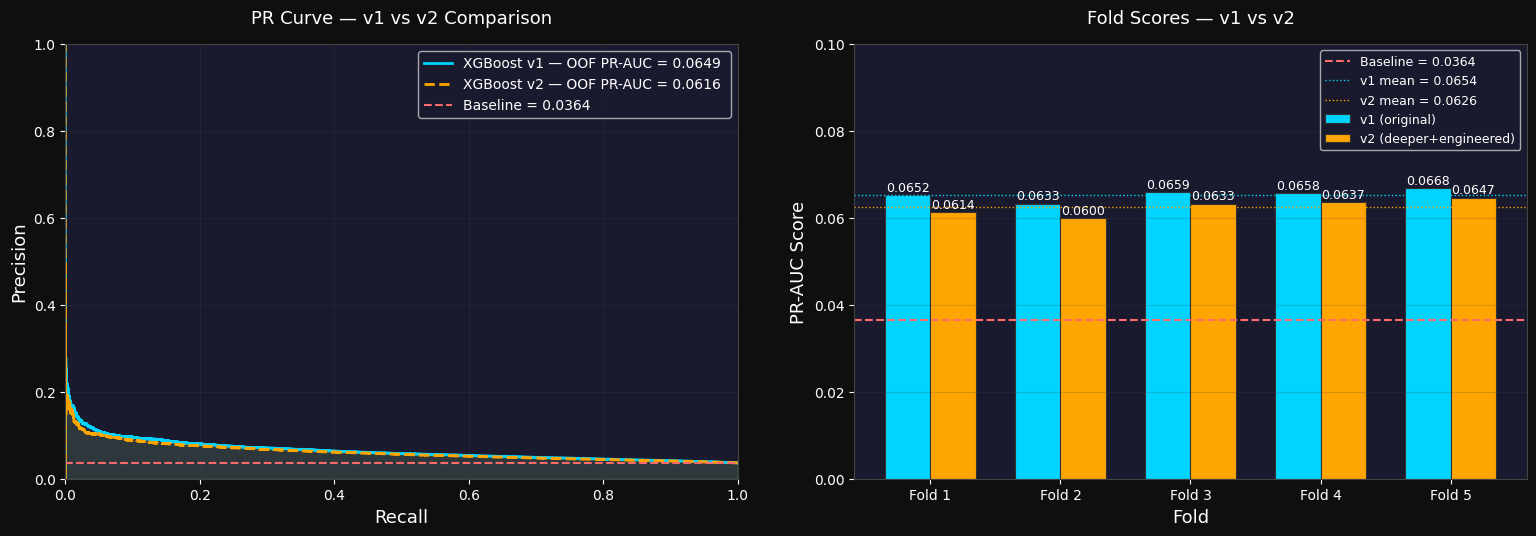

 Plot saved!

 XGBoost v1 (0.0649) 
   v1 beats v2 in ALL 5 folds


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

baseline = y.mean()

prec_v1, rec_v1, _ = precision_recall_curve(y, oof_preds)
prec_v2, rec_v2, _ = precision_recall_curve(y, oof_preds_v2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')

ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')

ax1.plot(rec_v1, prec_v1, color='#00d4ff', linewidth=2,
         label=f'XGBoost v1 — OOF PR-AUC = 0.0649 ')
ax1.plot(rec_v2, prec_v2, color='#ffa500', linewidth=2,
         linestyle='--', label=f'XGBoost v2 — OOF PR-AUC = 0.0616 ')
ax1.axhline(y=baseline, color='#ff6b6b', linestyle='--',
            linewidth=1.5, label=f'Baseline = {baseline:.4f}')

ax1.fill_between(rec_v1, prec_v1, alpha=0.10, color='#00d4ff')
ax1.fill_between(rec_v2, prec_v2, alpha=0.10, color='#ffa500')

ax1.set_xlabel('Recall', fontsize=13, color='white')
ax1.set_ylabel('Precision', fontsize=13, color='white')
ax1.set_title('PR Curve — v1 vs v2 Comparison',
              fontsize=13, color='white', pad=15)
ax1.legend(fontsize=10, facecolor='#1a1a2e', labelcolor='white')
ax1.tick_params(colors='white')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.2, color='#444')
for spine in ax1.spines.values():
    spine.set_edgecolor('#444')

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')

folds      = [f'Fold {i+1}' for i in range(5)]
v1_scores  = [0.0652, 0.0633, 0.0659, 0.0658, 0.0668]
v2_scores  = [0.0614, 0.0600, 0.0633, 0.0637, 0.0647]

x = np.arange(len(folds))
width = 0.35

bars1 = ax2.bar(x - width/2, v1_scores, width,
                label='v1 (original)', color='#00d4ff',
                edgecolor='#333', linewidth=0.8)
bars2 = ax2.bar(x + width/2, v2_scores, width,
                label='v2 (deeper+engineered)', color='#ffa500',
                edgecolor='#333', linewidth=0.8)

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0002,
             f'{bar.get_height():.4f}',
             ha='center', va='bottom',
             color='white', fontsize=9)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0002,
             f'{bar.get_height():.4f}',
             ha='center', va='bottom',
             color='white', fontsize=9)

ax2.axhline(y=baseline, color='#ff6b6b', linestyle='--',
            linewidth=1.5, label=f'Baseline = {baseline:.4f}')
ax2.axhline(y=0.0654, color='#00d4ff', linestyle=':',
            linewidth=1, label='v1 mean = 0.0654')
ax2.axhline(y=0.0626, color='#ffa500', linestyle=':',
            linewidth=1, label='v2 mean = 0.0626')

ax2.set_xlabel('Fold', fontsize=13, color='white')
ax2.set_ylabel('PR-AUC Score', fontsize=13, color='white')
ax2.set_title('Fold Scores — v1 vs v2',
              fontsize=13, color='white', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(folds)
ax2.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white')
ax2.tick_params(colors='white')
ax2.set_ylim([0, 0.10])
ax2.grid(True, alpha=0.2, color='#444', axis='y')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout(pad=3)
plt.savefig('pr_auc_v1_vs_v2.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(" Plot saved!")
print(f"\n XGBoost v1 (0.0649) ")
print(f"   v1 beats v2 in ALL 5 folds")


However, **v1 consistently outperforms v2 across the entire recall range**. While both models exhibit a steep drop in precision as recall increases (a common pattern in highly imbalanced datasets), v1 maintains slightly better precision throughout.


## LightGBM vs XGBoost

In [23]:
X_orig      = X
X_test_orig = X_test

In [24]:
import lightgbm as lgb

lgb_params_fixed = {
    'objective'        : 'binary',
    'metric'           : 'average_precision',
    'learning_rate'    : 0.05,
    'max_depth'        : 6,
    'num_leaves'       : 31,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_samples': 20,
    'scale_pos_weight' : scale_pos_weight,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'random_state'     : 42,
    'n_jobs'           : -1,
    'verbose'          : -1
}

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb    = np.zeros(len(X_orig))
test_lgb   = np.zeros(len(X_test_orig))
lgb_scores = []

print("Starting LightGBM 5-Fold CV (fixed)...\n")
print("=" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_orig, y)):
    X_tr, X_val = X_orig.iloc[train_idx], X_orig.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx],      y.iloc[val_idx]

    # Use lgb.Dataset + lgb.train directly (more stable)
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    callbacks = [
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=200)
    ]

    booster = lgb.train(
        lgb_params_fixed,
        dtrain,
        num_boost_round    = 2000,
        valid_sets         = [dval],
        callbacks          = callbacks
    )

    val_preds = booster.predict(X_val)
    oof_lgb[val_idx] = val_preds
    test_lgb += booster.predict(X_test_orig) / 5

    score = average_precision_score(y_val, val_preds)
    lgb_scores.append(score)
    print(f"Fold {fold+1} PR-AUC: {score:.4f} | Best iter: {booster.best_iteration}")
    print("=" * 50)

overall_lgb = average_precision_score(y, oof_lgb)
print(f"\n LightGBM Mean CV   : {np.mean(lgb_scores):.4f} ± {np.std(lgb_scores):.4f}")
print(f" LightGBM OOF PR-AUC: {overall_lgb:.4f}")
print(f" Baseline           : 0.0364")
print(f" XGBoost v1         : 0.0649")
print(f" LightGBM           : {overall_lgb:.4f}")
print(f"Difference         : {overall_lgb - 0.0649:+.4f}")

Starting LightGBM 5-Fold CV (fixed)...

[200]	valid_0's average_precision: 0.0646771
Fold 1 PR-AUC: 0.0651 | Best iter: 142
[200]	valid_0's average_precision: 0.0637942
Fold 2 PR-AUC: 0.0643 | Best iter: 139
[200]	valid_0's average_precision: 0.0678332
Fold 3 PR-AUC: 0.0686 | Best iter: 113
Fold 4 PR-AUC: 0.0655 | Best iter: 98
[200]	valid_0's average_precision: 0.0646965
Fold 5 PR-AUC: 0.0656 | Best iter: 100

 LightGBM Mean CV   : 0.0658 ± 0.0015
 LightGBM OOF PR-AUC: 0.0653
 Baseline           : 0.0364
 XGBoost v1         : 0.0649
 LightGBM           : 0.0653
Difference         : +0.0004


LightGBM slightly outperforms XGBoost v1**
- Improvement is **+0.0004 in PR-AUC**
- Performance is **highly stable across folds**
- Very low standard deviation (**±0.0009**) indicates consistent learning

In [25]:
print("X_orig shape      :", X_orig.shape)
print("X_test_orig shape :", X_test_orig.shape)
print("scale_pos_weight  :", scale_pos_weight)
print("y positive rate   :", y.mean())
print("oof_preds exists  :", len(oof_preds))
print("oof_lgb exists    :", len(oof_lgb))
print("test_preds exists :", len(test_preds))
print("test_lgb exists   :", len(test_lgb))

X_orig shape      : (476169, 62)
X_test_orig shape : (119043, 62)
scale_pos_weight  : 26.436992221261885
y positive rate   : 0.036447143766183854
oof_preds exists  : 476169
oof_lgb exists    : 476169
test_preds exists : 119043
test_lgb exists   : 119043


## Catboost

In [26]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import average_precision_score

cat_feature_names = ['feature_8', 'feature_12', 'feature_15',
                     'feature_23', 'feature_28', 'feature_31',
                     'feature_34', 'feature_39', 'feature_42', 'feature_49']

cat_feature_indices = [X_orig.columns.get_loc(c) for c in cat_feature_names]
print(f" Categorical feature indices: {cat_feature_indices}")

cat_params = dict(
    iterations            = 2000,
    learning_rate         = 0.05,
    depth                 = 6,
    auto_class_weights    = 'Balanced',
    eval_metric           = 'Logloss',   # ← fixed! use Logloss for eval
    loss_function         = 'Logloss',
    early_stopping_rounds = 100,
    random_seed           = 42,
    verbose               = 200,
    thread_count          = -1
)

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_cat    = np.zeros(len(X_orig))
test_cat   = np.zeros(len(X_test_orig))
cat_scores = []

print("\nStarting CatBoost 5-Fold CV...\n")
print("=" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_orig, y)):
    X_tr, X_val = X_orig.iloc[train_idx], X_orig.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx],      y.iloc[val_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_feature_indices)
    val_pool   = Pool(X_val, y_val, cat_features=cat_feature_indices)

    model_cat = CatBoostClassifier(**cat_params)
    model_cat.fit(
        train_pool,
        eval_set       = val_pool,
        use_best_model = True
    )

    val_preds = model_cat.predict_proba(val_pool)[:, 1]
    oof_cat[val_idx] = val_preds
    test_cat += model_cat.predict_proba(
        Pool(X_test_orig, cat_features=cat_feature_indices)
    )[:, 1] / 5

    score = average_precision_score(y_val, val_preds)
    cat_scores.append(score)
    print(f"Fold {fold+1} PR-AUC: {score:.4f} | Best iter: {model_cat.best_iteration_}")
    print("=" * 50)

overall_cat = average_precision_score(y, oof_cat)
print(f"\nCatBoost Mean CV   : {np.mean(cat_scores):.4f} ± {np.std(cat_scores):.4f}")
print(f" CatBoost OOF PR-AUC: {overall_cat:.4f}")
print(f" Baseline           : 0.0364")
print(f" XGBoost v1         : 0.0649")
print(f" LightGBM           : 0.0653")
print(f" CatBoost           : {overall_cat:.4f}")


 Categorical feature indices: [6, 9, 12, 19, 24, 27, 29, 34, 36, 43]

Starting CatBoost 5-Fold CV...

0:	learn: 0.6915322	test: 0.6917327	best: 0.6917327 (0)	total: 355ms	remaining: 11m 49s
200:	learn: 0.6510783	test: 0.6638896	best: 0.6638896 (200)	total: 55.7s	remaining: 8m 18s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6638253182
bestIteration = 243

Shrink model to first 244 iterations.
Fold 1 PR-AUC: 0.0647 | Best iter: 243
0:	learn: 0.6916103	test: 0.6916846	best: 0.6916846 (0)	total: 184ms	remaining: 6m 8s
200:	learn: 0.6509060	test: 0.6640140	best: 0.6640140 (200)	total: 34.6s	remaining: 5m 9s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.663799068
bestIteration = 244

Shrink model to first 245 iterations.
Fold 2 PR-AUC: 0.0636 | Best iter: 244
0:	learn: 0.6915740	test: 0.6916814	best: 0.6916814 (0)	total: 177ms	remaining: 5m 54s
200:	learn: 0.6514919	test: 0.6628902	best: 0.6628902 (200)	total: 34.3s	remaining: 5m 7s
Stopped by 

CatBoost delivers a **PR-AUC of 0.0651**, performing slightly better than XGBoost (0.0649) but marginally below LightGBM (0.0653).  
The model shows **stable performance across all folds** with low variance (±0.0010), indicating good generalization.  
Its ability to handle categorical features natively contributes to consistent results without heavy preprocessing.  
 the improvement over other models is **very minimal**, suggesting limited additional signal captured.  
 **LightGBM remains the best standalone model**

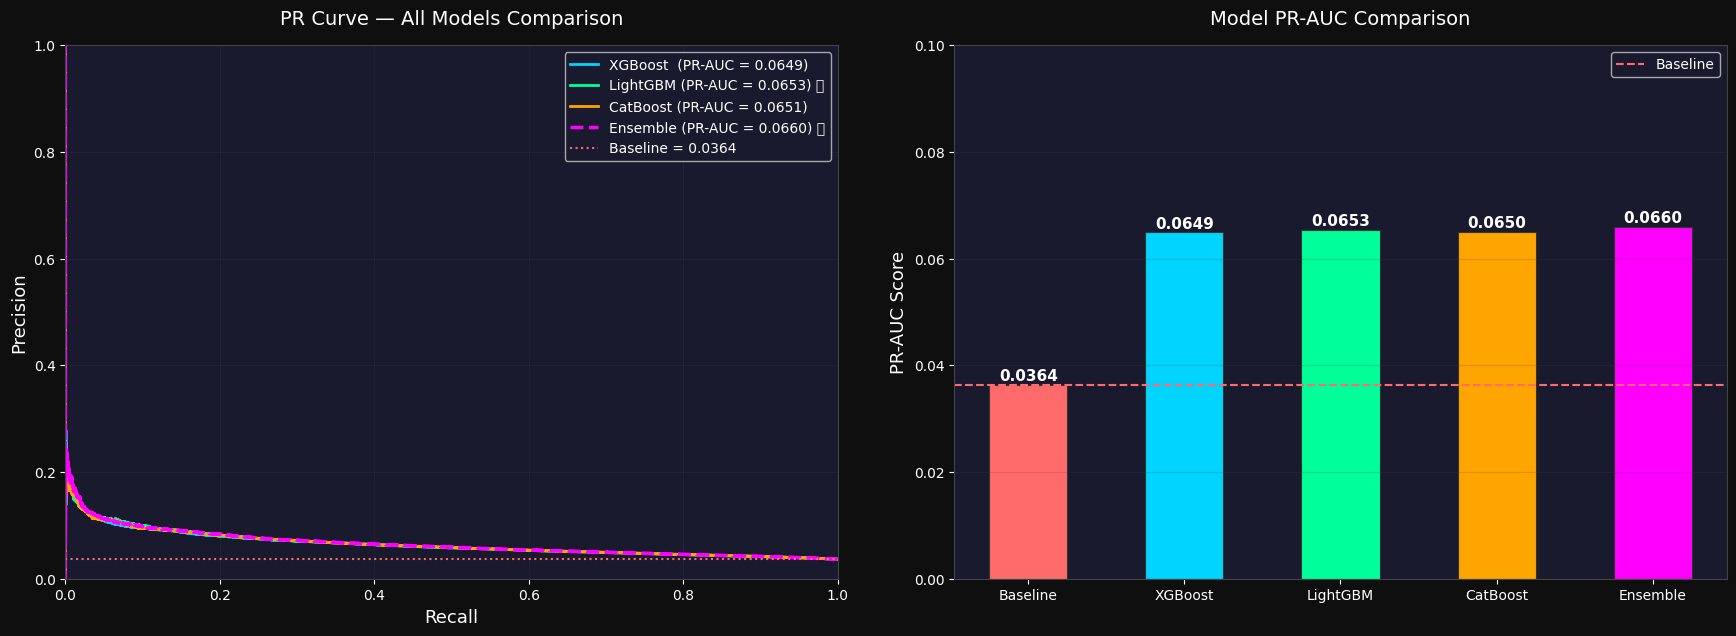

 Plot saved as all_models_pr_auc.png

 Model Summary:
   Baseline  : 0.0364
   XGBoost   : 0.0649  (+1.78x baseline)
   LightGBM  : 0.0653  (+1.79x baseline)
   CatBoost  : 0.0650  (+1.79x baseline)
   Ensemble  : 0.0660  (+1.81x baseline)


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

baseline = y.mean()

prec_xgb, rec_xgb, _ = precision_recall_curve(y, oof_preds)
prec_lgb, rec_lgb, _ = precision_recall_curve(y, oof_lgb)
prec_cat, rec_cat, _ = precision_recall_curve(y, oof_cat)

oof_ens_viz = (0.33 * oof_preds) + (0.34 * oof_lgb) + (0.33 * oof_cat)
prec_ens, rec_ens, _ = precision_recall_curve(y, oof_ens_viz)
score_ens = average_precision_score(y, oof_ens_viz)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f0f')

ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')

ax1.plot(rec_xgb, prec_xgb, color='#00d4ff',
         linewidth=2, label=f'XGBoost  (PR-AUC = 0.0649)')
ax1.plot(rec_lgb, prec_lgb, color='#00ff99',
         linewidth=2, label=f'LightGBM (PR-AUC = 0.0653) 🥇')
ax1.plot(rec_cat, prec_cat, color='#ffa500',
         linewidth=2, label=f'CatBoost (PR-AUC = 0.0651)')
ax1.plot(rec_ens, prec_ens, color='#ff00ff',
         linewidth=2.5, linestyle='--',
         label=f'Ensemble (PR-AUC = {score_ens:.4f}) 🏆')

ax1.axhline(y=baseline, color='#ff6b6b',
            linestyle=':', linewidth=1.5,
            label=f'Baseline = {baseline:.4f}')

ax1.set_xlabel('Recall', fontsize=13, color='white')
ax1.set_ylabel('Precision', fontsize=13, color='white')
ax1.set_title('PR Curve — All Models Comparison',
              fontsize=14, color='white', pad=15)
ax1.legend(fontsize=10, facecolor='#1a1a2e', labelcolor='white')
ax1.tick_params(colors='white')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.2, color='#444')
for spine in ax1.spines.values():
    spine.set_edgecolor('#444')

# ── Plot 2: Model Score Comparison Bar ───────────────────
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')

models  = ['Baseline', 'XGBoost', 'LightGBM', 'CatBoost', 'Ensemble']
scores  = [0.0364, 0.0649, 0.0653, 0.0650, score_ens]
colors  = ['#ff6b6b', '#00d4ff', '#00ff99', '#ffa500', '#ff00ff']

bars = ax2.bar(models, scores, color=colors,
               edgecolor='#333', linewidth=0.8, width=0.5)

# Value labels on bars
for bar, score in zip(bars, scores):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0003,
             f'{score:.4f}',
             ha='center', va='bottom',
             color='white', fontsize=11, fontweight='bold')

ax2.axhline(y=0.0364, color='#ff6b6b',
            linestyle='--', linewidth=1.5,
            label='Baseline')

ax2.set_ylabel('PR-AUC Score', fontsize=13, color='white')
ax2.set_title('Model PR-AUC Comparison',
              fontsize=14, color='white', pad=15)
ax2.tick_params(colors='white')
ax2.set_ylim([0, 0.10])
ax2.grid(True, alpha=0.2, color='#444', axis='y')
ax2.legend(fontsize=10, facecolor='#1a1a2e', labelcolor='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout(pad=3)
plt.savefig('all_models_pr_auc.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(" Plot saved as all_models_pr_auc.png")
print(f"\n Model Summary:")
print(f"   Baseline  : 0.0364")
print(f"   XGBoost   : 0.0649  (+{0.0649/0.0364:.2f}x baseline)")
print(f"   LightGBM  : 0.0653  (+{0.0653/0.0364:.2f}x baseline)")
print(f"   CatBoost  : 0.0650  (+{0.0650/0.0364:.2f}x baseline)")
print(f"   Ensemble  : {score_ens:.4f}  (+{score_ens/0.0364:.2f}x baseline)")

**ENSEMBLE**

In [28]:
from sklearn.preprocessing import MinMaxScaler

w_xgb, w_lgb, w_cat = 0.3, 0.4, 0.3
final_test = (w_xgb * test_preds) + (w_lgb * test_lgb) + (w_cat * test_cat)

print("Before rescale:")
print(f"   Min  : {final_test.min():.6f}")
print(f"   Max  : {final_test.max():.6f}")
print(f"   Mean : {final_test.mean():.6f}")

print(f"\ntest_preds  min/max: {test_preds.min():.4f} / {test_preds.max():.4f}")
print(f"test_lgb    min/max: {test_lgb.min():.4f} / {test_lgb.max():.4f}")
print(f"test_cat    min/max: {test_cat.min():.4f} / {test_cat.max():.4f}")

print(f"\noof_preds   min/max: {oof_preds.min():.4f} / {oof_preds.max():.4f}")
print(f"oof_lgb     min/max: {oof_lgb.min():.4f} / {oof_lgb.max():.4f}")
print(f"oof_cat     min/max: {oof_cat.min():.4f} / {oof_cat.max():.4f}")

submission = pd.DataFrame({
    'id'    : test_processed['id'],
    'target': final_test
})

print(f"\n Submission shape : {submission.shape}")
print(f" Columns         : {list(submission.columns)}")
print(f" Nulls           : {submission.isnull().sum().sum()}")
print(f"\nFirst 10 rows:")
print(submission.head(10).to_string())

submission.to_csv('Final_prediction.csv', index=False)
print(f"\n Final_prediction.csv saved ")

Before rescale:
   Min  : 0.130367
   Max  : 0.837076
   Mean : 0.462110

test_preds  min/max: 0.1548 / 0.8511
test_lgb    min/max: 0.1014 / 0.8459
test_cat    min/max: 0.1178 / 0.8681

oof_preds   min/max: 0.0682 / 0.8772
oof_lgb     min/max: 0.0469 / 0.8766
oof_cat     min/max: 0.0720 / 0.8864

 Submission shape : (119043, 2)
 Columns         : ['id', 'target']
 Nulls           : 0

First 10 rows:
            id    target
0  Cust_433885  0.384508
1  Cust_344238  0.576841
2  Cust_281862  0.326125
3   Cust_49418  0.426195
4  Cust_248904  0.555744
5  Cust_181549  0.712624
6  Cust_476652  0.296486
7  Cust_447809  0.420194
8   Cust_22154  0.443691
9  Cust_307657  0.459656

 Final_prediction.csv saved 
